<a href="https://colab.research.google.com/github/aryanp2107/100-ML-Projects/blob/main/Day59_U_Nets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.10.0+cu128
Device: cuda


In [2]:
"""
COMPUTER VISION TASKS

1. IMAGE CLASSIFICATION
   Input: Image
   Output: Single label
   "This image contains a cat"

2. OBJECT DETECTION
   Input: Image
   Output: Bounding boxes + labels
   "There's a cat at coordinates (x1,y1,x2,y2)"

3. SEMANTIC SEGMENTATION
   Input: Image
   Output: Per-pixel classification
   "These exact pixels belong to the cat"

4. INSTANCE SEGMENTATION
   Input: Image
   Output: Per-pixel + instance IDs
   "These pixels are cat #1, those are cat #2"

"""

'\nCOMPUTER VISION TASKS\n\n1. IMAGE CLASSIFICATION\n   Input: Image\n   Output: Single label\n   "This image contains a cat"\n   \n2. OBJECT DETECTION\n   Input: Image\n   Output: Bounding boxes + labels\n   "There\'s a cat at coordinates (x1,y1,x2,y2)"\n   \n3. SEMANTIC SEGMENTATION\n   Input: Image\n   Output: Per-pixel classification\n   "These exact pixels belong to the cat"\n   \n4. INSTANCE SEGMENTATION\n   Input: Image\n   Output: Per-pixel + instance IDs\n   "These pixels are cat #1, those are cat #2"\n\n'

In [3]:
# Download dataset
import urllib.request
import tarfile

data_dir = 'oxford_pets'
os.makedirs(data_dir, exist_ok=True)

# Download images
images_url = 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz'
masks_url = 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz'

if not os.path.exists(f'{data_dir}/images'):
    print("Downloading images...")
    urllib.request.urlretrieve(images_url, f'{data_dir}/images.tar.gz')
    with tarfile.open(f'{data_dir}/images.tar.gz', 'r:gz') as tar:
        tar.extractall(data_dir)
    print("Images downloaded!")

if not os.path.exists(f'{data_dir}/annotations'):
    print("Downloading annotations...")
    urllib.request.urlretrieve(masks_url, f'{data_dir}/annotations.tar.gz')
    with tarfile.open(f'{data_dir}/annotations.tar.gz', 'r:gz') as tar:
        tar.extractall(data_dir)
    print("Annotations downloaded!")

print("Dataset ready!")

Images downloaded!
Annotations downloaded!
Dataset ready!


In [4]:
import glob

image_paths = sorted(glob.glob(f'{data_dir}/images/*.jpg'))
mask_paths = sorted(glob.glob(f'{data_dir}/annotations/trimaps/*.png'))

print(f"FOund {len(image_paths)} images")
print(f"FOund {len(mask_paths)} masks")
print(f"\n First image: {image_paths[0]}")
print(f"\n First mask: {mask_paths[0]}")

FOund 7390 images
FOund 7390 masks

 First image: oxford_pets/images/Abyssinian_1.jpg

 First mask: oxford_pets/annotations/trimaps/Abyssinian_1.png


In [5]:
#matching the images with the masks
def get_mask_path(image_path):
  filename = os.path.basename(image_path).replace('.jpg', '.png')
  return f'{data_dir}/annotations/trimaps/{filename}'

# Filtering to only images that have masks
valid_pairs = []
for image_path in image_paths:
  mask_path = get_mask_path(image_path)
  if os.path.exists(mask_path):
    valid_pairs.append((image_path, mask_path))

print(f"Found {len(valid_pairs)} valid pairs")
print(f"\n First pair: {valid_pairs[0]}")

Found 7390 valid pairs

 First pair: ('oxford_pets/images/Abyssinian_1.jpg', 'oxford_pets/annotations/trimaps/Abyssinian_1.png')


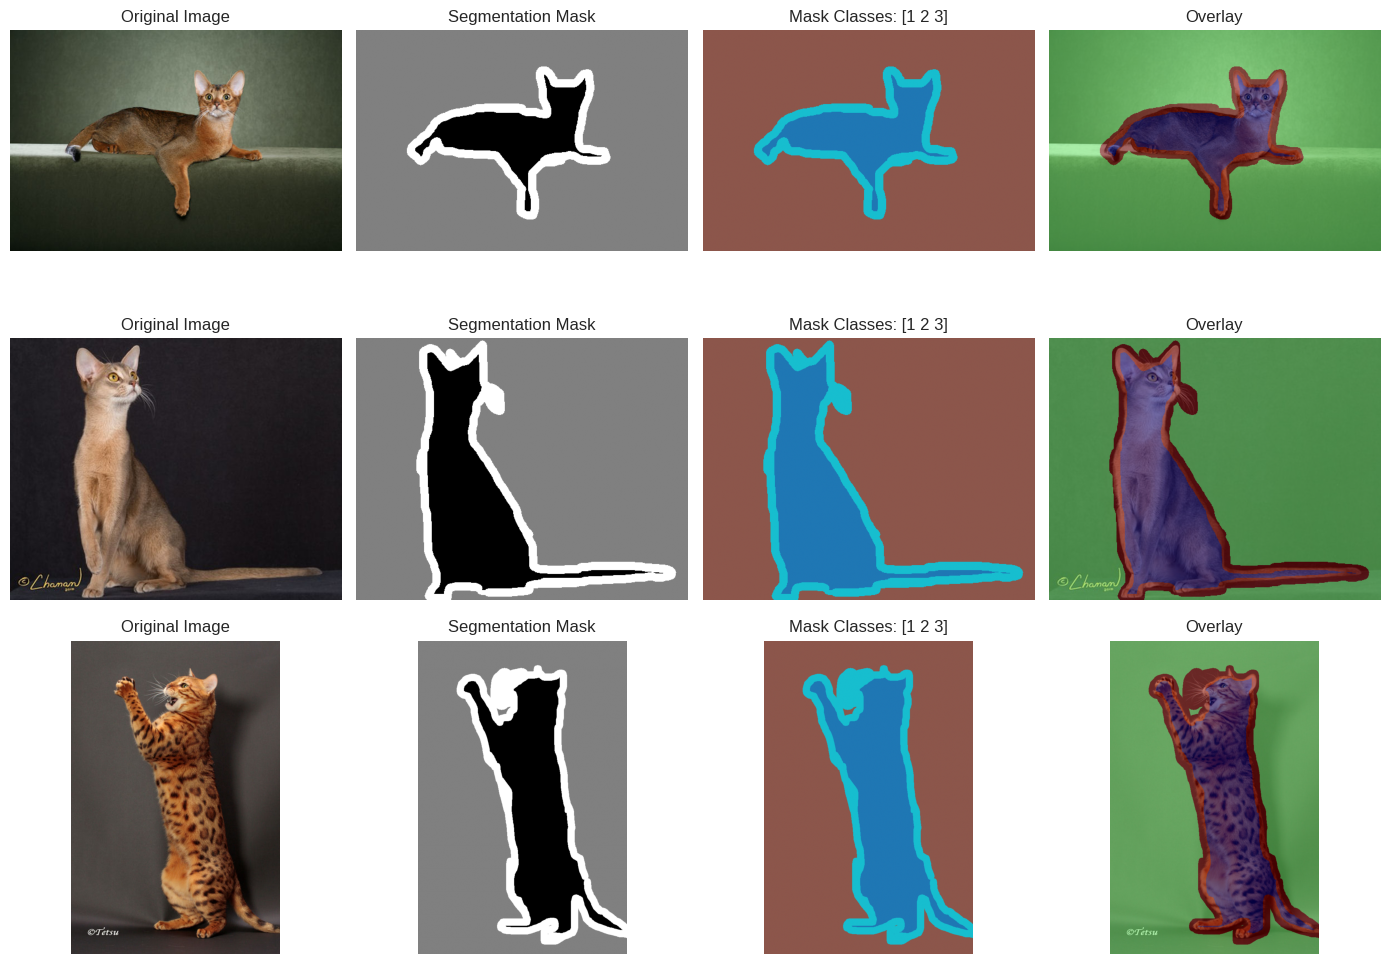

In [6]:
#visualizing some samples
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i in range(3):
  img_path, mask_path = valid_pairs[i * 100]

  img = Image.open(img_path).convert('RGB')
  mask = Image.open(mask_path)

  #original image
  axes[i, 0].imshow(img)
  axes[i, 0].set_title('Original Image')
  axes[i, 0].axis('off')

  #mask
  axes[i, 1].imshow(mask, cmap='gray')
  axes[i, 1].set_title('Segmentation Mask')
  axes[i, 1].axis('off')

  #mask values
  mask_np = np.array(mask)
  axes[i, 2].imshow(mask_np, cmap='tab10')
  axes[i, 2].set_title(f'Mask Classes: {np.unique(mask_np)}')
  axes[i, 2].axis('off')

  # The overlay
  axes[i, 3].imshow(img)
  axes[i, 3].imshow(mask_np, alpha=0.5, cmap='jet')
  axes[i, 3].set_title('Overlay')
  axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

Dataset Class

In [7]:
IMG_SIZE = 128

class PetSegmentationDataset(Dataset):
  def __init__(self, pairs, img_size=12, augment=False):
    self.pairs = pairs
    self.img_size = img_size
    self.augment = augment

    self.img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, idx):
    img_path, mask_path = self.pairs[idx]

    #loading the image
    img = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path)

    #Resize the mask
    mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

    #converting mask to tensor
    # Classes: 1=pet, 2=background, 3=border
    # Convert to: 0=background, 1=pet (binary segmentation)
    mask = np.array(mask)
    mask = (mask == 1).astype(np.float32)  # 1 where pet, else 0
    mask = torch.tensor(mask).unsqueeze(0)    #Added channel dim

    img = self.img_transform(img)

    return img, mask

print('Dataset class defined')


Dataset class defined


In [8]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(valid_pairs, test_size=0.2, random_state=42)

print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs: {len(val_pairs)}")

Train pairs: 5912
Val pairs: 1478


In [9]:
BATCH_SIZE = 32

train_dataset = PetSegmentationDataset(train_pairs, IMG_SIZE, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = PetSegmentationDataset(val_pairs, IMG_SIZE, augment=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 185
Val batches: 47


In [10]:
# Check batch
images, masks = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape: {masks.shape}")
print(f"Mask values: {masks.unique()}")

Image batch shape: torch.Size([32, 3, 128, 128])
Mask batch shape: torch.Size([32, 1, 128, 128])
Mask values: tensor([0., 1.])


U-Net Model

In [11]:
class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.double_conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.double_conv(x)

class Down(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.maxpool_conv = nn.Sequential(
        nn.MaxPool2d(2),
        DoubleConv(in_channels, out_channels)
    )

  def forward(self, x):
    return self.maxpool_conv(x)

class Up(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
    self.conv = DoubleConv(in_channels, out_channels)

  def forward(self, x1, x2):
    # x1: from decoder (to be upsampled)
    # x2: skipped connectionfrom the encoder

    x1 = self.up(x1)

    #handling the size mismatch
    diffy = x2.size()[2] - x1.size()[2]
    diffx = x2.size()[3] - x1.size()[3]

    x1 = F.pad(x1, [diffx // 2, diffx - diffx // 2,
                    diffy // 2, diffy - diffy // 2])

    x = torch.cat([x2, x1], dim=1)
    return self.conv(x)

class UNet(nn.Module):
  def __init__(self, n_channels=3, n_classes=1):
    super().__init__()
    self.n_channels = n_channels
    self.n_classes = n_classes

    # Encoder (contracting path)
    self.inc = DoubleConv(n_channels, 64)
    self.down1 =  Down(64, 128)
    self.down2 = Down(128, 256)
    self.down3 = Down(256, 512)
    self.down4 = Down(512, 1024)

    #Encoder (expanding)
    self.up1 = Up(1024, 512)
    self.up2 = Up(512, 256)
    self.up3 = Up(256, 128)
    self.up4 = Up(128, 64)

    self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

  def forward(self, x):
    # Encoder
    x1 = self.inc(x)
    x2 = self.down1(x1)
    x3 = self.down2(x2)
    x4 = self.down3(x3)
    x5 = self.down4(x4)

    # the decoder with skip connections
    x = self.up1(x5, x4)
    x = self.up2(x, x3)
    x = self.up3(x, x2)
    x = self.up4(x, x1)

    # Output layer
    logits = self.outc(x)
    return logits

print('UNet model defined')


UNet model defined


In [12]:
model = UNet(n_channels=3, n_classes=1).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 31043521
Trainable parameters: 31043521


In [13]:
test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
test_output = model(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Ouput shape: {test_output.shape}")

Input shape: torch.Size([1, 3, 128, 128])
Ouput shape: torch.Size([1, 1, 128, 128])


In [14]:
"""

Segmentation losses & Metrics

1. BINARY CROSS ENTROPY (BCE)
   Standard pixel-wise classification loss.
   Problem: Doesn't handle class imbalance well.

2. DICE LOSS
   Based on Dice coefficient (F1 score for segmentation).

   Dice = 2 × |A ∩ B| / (|A| + |B|)
   Dice Loss = 1 - Dice

   Better for imbalanced classes (small objects).

3. IoU (Intersection over Union) - METRIC
   IoU = |A ∩ B| / |A ∪ B|

   Also called Jaccard Index.
   Standard metric for segmentation quality.


"""

"\n\nSegmentation losses & Metrics\n\n1. BINARY CROSS ENTROPY (BCE)\n   Standard pixel-wise classification loss.\n   Problem: Doesn't handle class imbalance well.\n\n2. DICE LOSS\n   Based on Dice coefficient (F1 score for segmentation).\n   \n   Dice = 2 × |A ∩ B| / (|A| + |B|)\n   Dice Loss = 1 - Dice\n   \n   Better for imbalanced classes (small objects).\n\n3. IoU (Intersection over Union) - METRIC\n   IoU = |A ∩ B| / |A ∪ B|\n   \n   Also called Jaccard Index.\n   Standard metric for segmentation quality.\n\n\n"

In [15]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)

        # Flatten
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)

        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)

        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice(pred, target)


def calculate_iou(pred, target, threshold=0.5):
    """Calculate IoU (Intersection over Union)"""
    pred = (torch.sigmoid(pred) > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()

print("Loss functions and metrics defined")

Loss functions and metrics defined


In [16]:
criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print('The training functions defined')

The training functions defined


Training

In [17]:
def train_epoch(model, loader, criterion, optimizer):
  model.train()
  total_loss = 0
  total_iou = 0

  for images, masks in loader:
    images, masks = images.to(device), masks.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, masks)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_iou += calculate_iou(outputs, masks)

  return total_loss / len(loader), total_iou / len(loader)

def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0
  total_iou = 0

  with torch.no_grad():
    for images, masks in loader:
      images, masks = images.to(device), masks.to(device)

      outputs = model(images)
      loss = criterion(outputs, masks)

      total_loss += loss.item()
      total_iou += calculate_iou(outputs, masks)
  return total_loss  / len(loader), total_iou / len(loader)

print("The training functions defined")


The training functions defined


In [18]:
EPOCHS = 25

history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}
best_val_iou = 0

print(f"Training U-Net for {EPOCHS} epochs...")
print("="*70)

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_iou = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_iou = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)

    elapsed = time.time() - start_time

    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), 'best_unet.pt')
        marker = ' ✓ (saved)'
    else:
        marker = ''

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f} | "
          f"Time: {elapsed:.1f}s{marker}")

print(f"\nBest validation IoU: {best_val_iou:.4f}")

Training U-Net for 25 epochs...
Epoch  1/25 | Train Loss: 0.7935 | Train IoU: 0.5804 | Val Loss: 0.6189 | Val IoU: 0.6835 | Time: 115.1s ✓ (saved)
Epoch  2/25 | Train Loss: 0.5555 | Train IoU: 0.6990 | Val Loss: 0.5075 | Val IoU: 0.7289 | Time: 114.7s ✓ (saved)
Epoch  3/25 | Train Loss: 0.4625 | Train IoU: 0.7408 | Val Loss: 0.4370 | Val IoU: 0.7443 | Time: 114.7s ✓ (saved)
Epoch  4/25 | Train Loss: 0.4056 | Train IoU: 0.7648 | Val Loss: 0.4345 | Val IoU: 0.7505 | Time: 114.9s ✓ (saved)
Epoch  5/25 | Train Loss: 0.3624 | Train IoU: 0.7850 | Val Loss: 0.4093 | Val IoU: 0.7492 | Time: 114.4s
Epoch  6/25 | Train Loss: 0.3257 | Train IoU: 0.8039 | Val Loss: 0.3793 | Val IoU: 0.7644 | Time: 114.5s ✓ (saved)
Epoch  7/25 | Train Loss: 0.2956 | Train IoU: 0.8193 | Val Loss: 0.3479 | Val IoU: 0.7889 | Time: 114.9s ✓ (saved)
Epoch  8/25 | Train Loss: 0.2775 | Train IoU: 0.8288 | Val Loss: 0.3822 | Val IoU: 0.7769 | Time: 114.8s
Epoch  9/25 | Train Loss: 0.2554 | Train IoU: 0.8409 | Val Loss: 0.3

In [19]:
# Load best model
model.load_state_dict(torch.load('best_unet.pt'))
model.eval()
print("Loaded best model")

Loaded best model


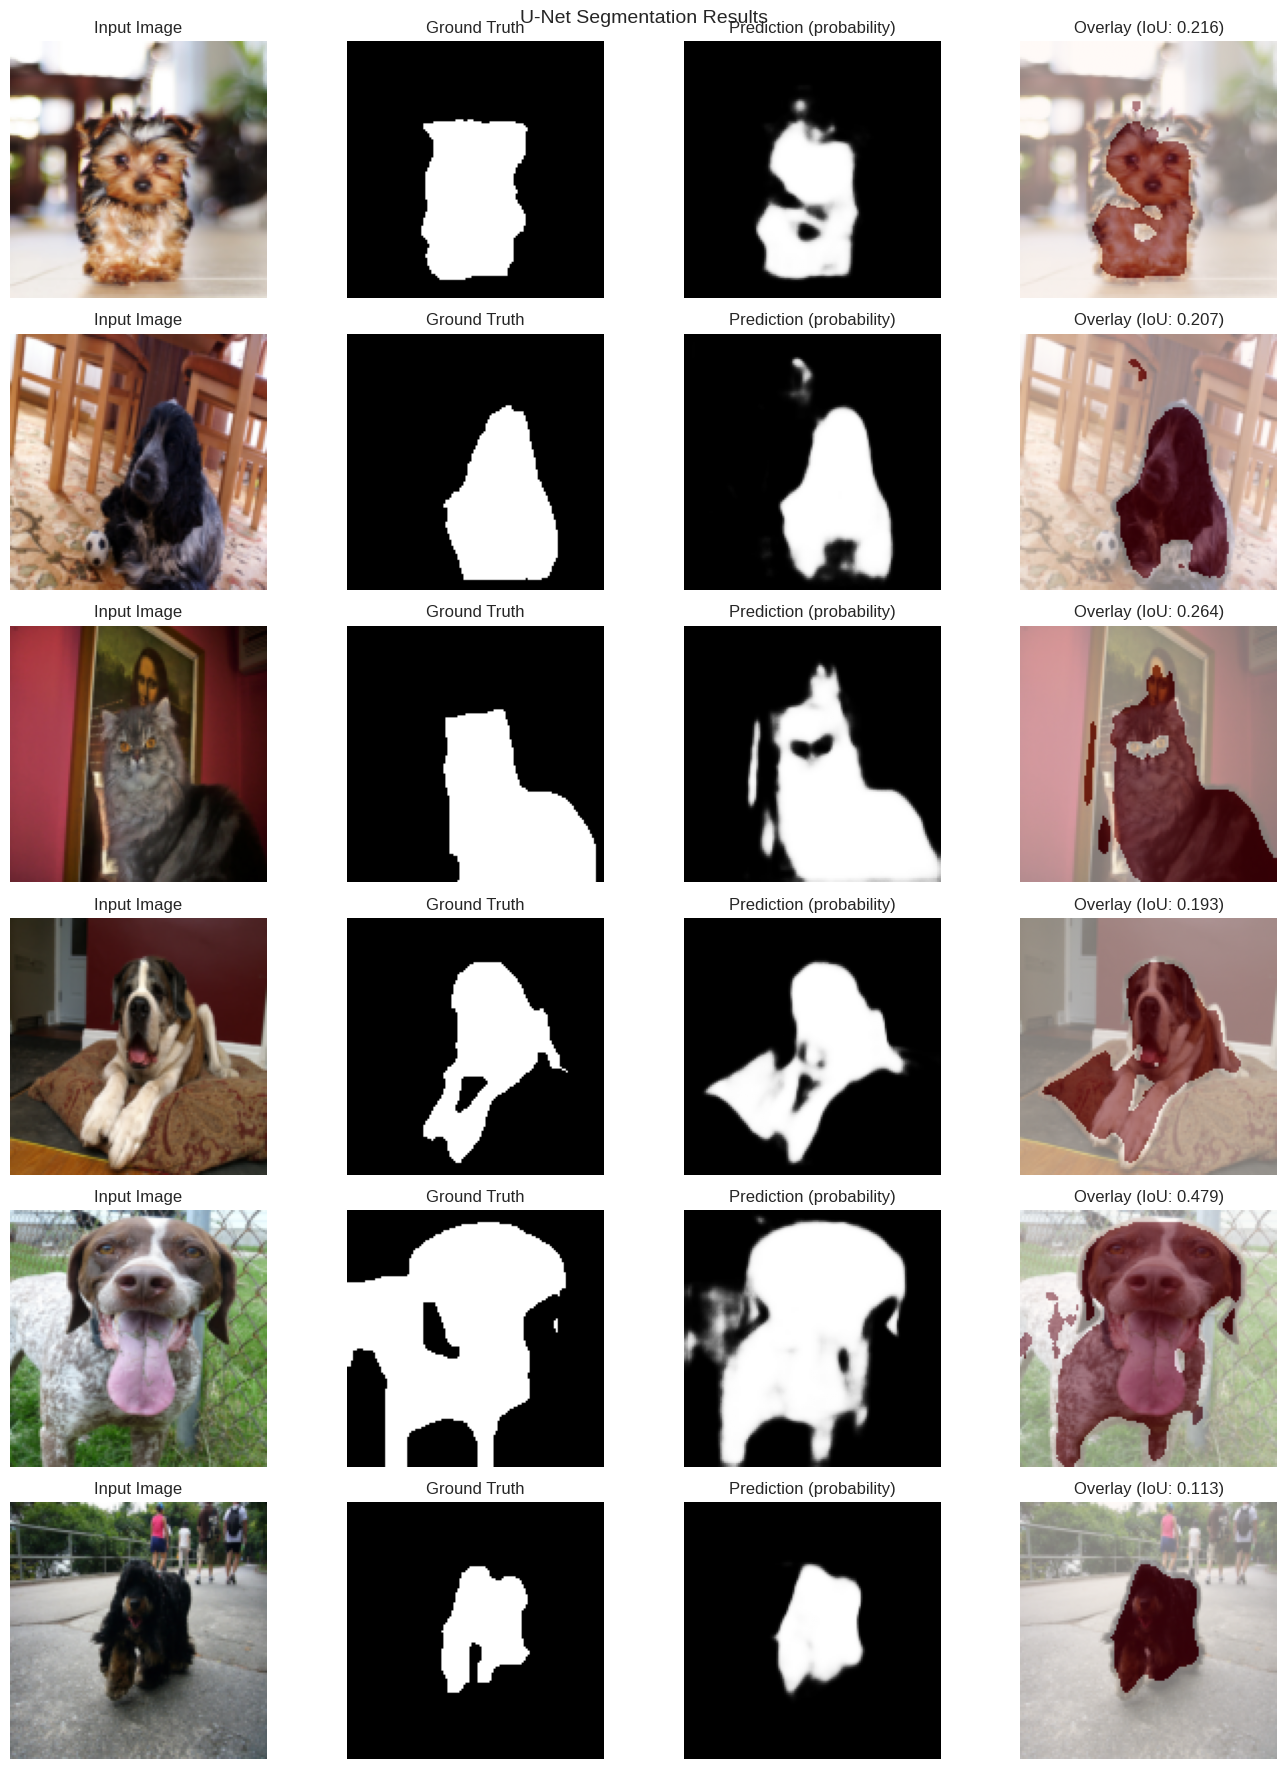

In [20]:
def denormalize(tensor):
    """Denormalize image tensor for visualization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def visualize_predictions(model, loader, n_samples=6):
    model.eval()

    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        preds = torch.sigmoid(model(images))

    fig, axes = plt.subplots(n_samples, 4, figsize=(14, n_samples * 3))

    for i in range(n_samples):
        # Original image
        img = denormalize(images[i].cpu()).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        # Ground truth mask
        gt_mask = masks[i, 0].cpu().numpy()
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        # Predicted mask
        pred_mask = preds[i, 0].cpu().numpy()
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title('Prediction (probability)')
        axes[i, 2].axis('off')

        # Thresholded prediction overlay
        pred_binary = (pred_mask > 0.5).astype(float)
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(pred_binary, alpha=0.5, cmap='Reds')
        iou = calculate_iou(preds[i:i+1], masks[i:i+1])
        axes[i, 3].set_title(f'Overlay (IoU: {iou:.3f})')
        axes[i, 3].axis('off')

    plt.suptitle('U-Net Segmentation Results', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, n_samples=6)

In [21]:
def segment_image(model, image_path, img_size=128):
    """Segment a single image"""
    model.eval()

    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    original_size = img.size

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor))

    # Resize prediction back to original size
    pred = pred.squeeze().cpu().numpy()
    pred_resized = np.array(Image.fromarray((pred * 255).astype(np.uint8)).resize(original_size))

    return img, pred_resized / 255.0

print("Segmentation function defined")

Segmentation function defined


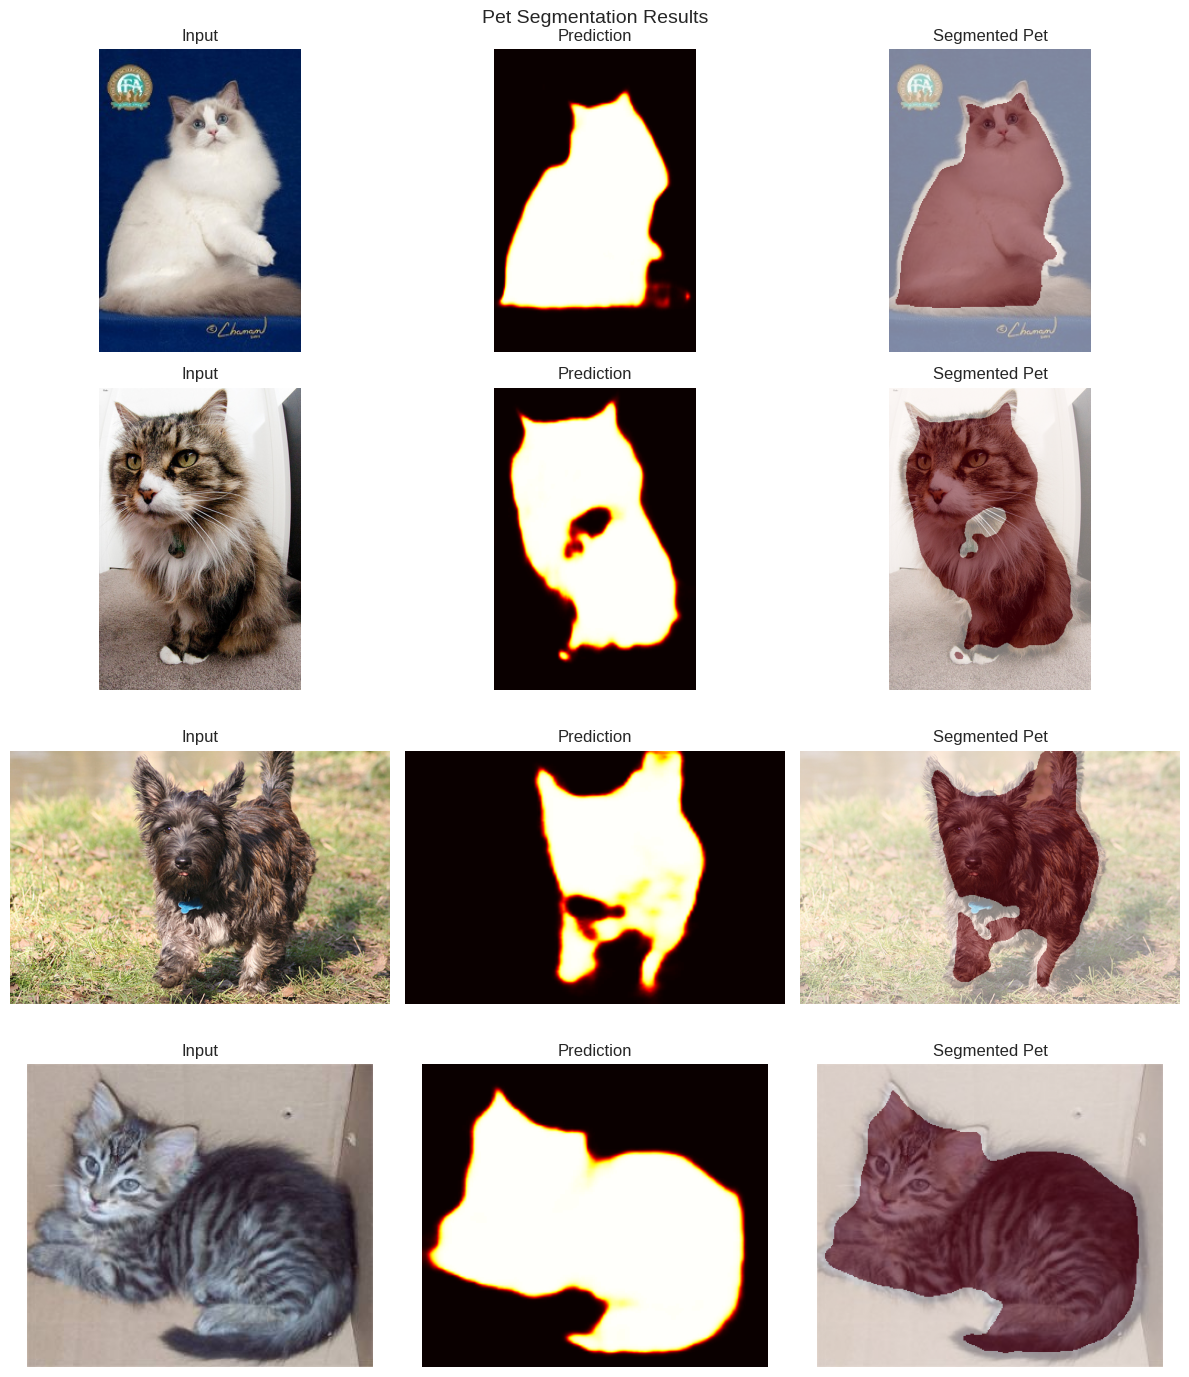

In [22]:
# Test on random validation images
test_indices = np.random.choice(len(val_pairs), 4, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for i, idx in enumerate(test_indices):
    img_path, mask_path = val_pairs[idx]

    img, pred = segment_image(model, img_path)

    # Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Input')
    axes[i, 0].axis('off')

    # Prediction
    axes[i, 1].imshow(pred, cmap='hot')
    axes[i, 1].set_title('Prediction')
    axes[i, 1].axis('off')

    # Overlay
    axes[i, 2].imshow(img)
    axes[i, 2].imshow(pred > 0.5, alpha=0.5, cmap='Reds')
    axes[i, 2].set_title('Segmented Pet')
    axes[i, 2].axis('off')

plt.suptitle('Pet Segmentation Results', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
from google.colab import drive

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-59-segmentation'
os.makedirs(save_path, exist_ok=True)

torch.save(model.state_dict(), f'{save_path}/unet_pets.pt')

print(f"Saved to: {save_path}")
print("\nTo load:")
print("  model = UNet(n_channels=3, n_classes=1)")
print("  model.load_state_dict(torch.load('unet_pets.pt'))")

Mounted at /content/drive
Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-59-segmentation

To load:
  model = UNet(n_channels=3, n_classes=1)
  model.load_state_dict(torch.load('unet_pets.pt'))
